In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
from diisco import names, DIISCO
import torch

timepoints = np.array([0, 5, 10, 15, 20, 25])
#timepoints = np.array([0, 25])

data = np.stack([[.2, .2, .6],
        [.2, .4, .4],
        [.25, .6, .15],
        [.3, .6, .1],
        [.4, .6, 0],
        [.45, .8, 0]], axis=0)
lambda_matrix = np.zeros((3, 3))
lambda_matrix[0,1] = 1
lambda_matrix[0,2] = 1
lambda_matrix[1,2] = 1
lambda_matrix[1,0] = 1
lambda_matrix[2,0] = 1
lambda_matrix[2,1] = 1

lambda_matrix = lambda_matrix.T
print(lambda_matrix)

[[0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 0.]]


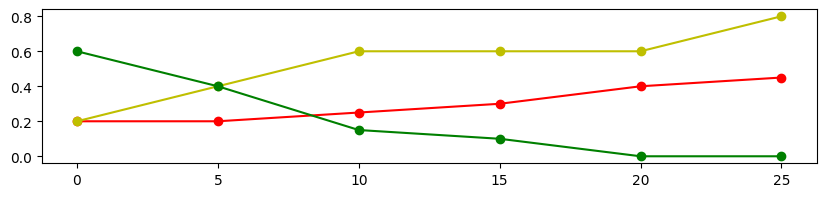

In [2]:
plt.figure(figsize = (10,2))
plt.plot(timepoints, data[:,0], '-ro')
plt.plot(timepoints, data[:,1], '-yo')
plt.plot(timepoints, data[:,2], '-go')
plt.show()

In [3]:
P = np.zeros((6,3,3))
P[0][0][1] = 0.29
P[0][0][2] = -0.33
P[0][1][0] = 0.39
P[0][1][2] = -0.42
P[0][2][0] = -0.46
P[0][2][1] = -0.43

P[1][0][1] = 0.33
P[1][0][2] = -0.38
P[1][1][0] = 0.08
P[1][1][2] = -0.19
P[1][2][0] = -0.18
P[1][2][1] = -0.24

P[2][0][1] = 0.23
P[2][0][2] = -0.21
P[2][1][0] = -0.14
P[2][1][2] = -0.07
P[2][2][0] = 0.1
P[2][2][1] = -0.12

P[3][0][1] = 0.11
P[3][0][2] = -0.09
P[3][1][0] = -0.04
P[3][1][2] = -0.2
P[3][2][0] = -0.06
P[3][2][1] = -0.26

P[4][0][1] = 0.26
P[4][0][2] = -0.3
P[4][1][0] = 0.11
P[4][1][2] = -0.23
P[4][2][0] = -0.32
P[4][2][1] = -0.35

P[5][0][1] = 0.45
P[5][0][2] = -0.48
P[5][1][0] = 0.31
P[5][1][2] = -0.28
P[5][2][0] = -0.36
P[5][2][1] = -0.27
print(P)

[[[ 0.    0.29 -0.33]
  [ 0.39  0.   -0.42]
  [-0.46 -0.43  0.  ]]

 [[ 0.    0.33 -0.38]
  [ 0.08  0.   -0.19]
  [-0.18 -0.24  0.  ]]

 [[ 0.    0.23 -0.21]
  [-0.14  0.   -0.07]
  [ 0.1  -0.12  0.  ]]

 [[ 0.    0.11 -0.09]
  [-0.04  0.   -0.2 ]
  [-0.06 -0.26  0.  ]]

 [[ 0.    0.26 -0.3 ]
  [ 0.11  0.   -0.23]
  [-0.32 -0.35  0.  ]]

 [[ 0.    0.45 -0.48]
  [ 0.31  0.   -0.28]
  [-0.36 -0.27  0.  ]]]


In [4]:
noise = np.random.normal(loc=0, scale=0.07, size=P.shape)
noisy_P = np.zeros((6,3,3))
for i in range(6):
    noisy_P[i][0][1] = max(-1,min(P[i][0][1] + noise[i][0][1],1))
    noisy_P[i][0][2] = max(-1,min(P[i][0][2] + noise[i][0][2],1))
    noisy_P[i][1][0] = max(-1,min(P[i][1][0] + noise[i][1][0],1))
    noisy_P[i][1][2] = max(-1,min(P[i][1][2] + noise[i][1][2],1))
    noisy_P[i][2][0] = max(-1,min(P[i][2][0] + noise[i][2][0],1))
    noisy_P[i][2][1] = max(-1,min(P[i][2][1] + noise[i][2][1],1))
print(noisy_P)

[[[ 0.          0.40929294 -0.29676889]
  [ 0.35420442  0.         -0.50597072]
  [-0.41160115 -0.37714772  0.        ]]

 [[ 0.          0.31212923 -0.33607155]
  [ 0.2050354   0.         -0.23997491]
  [-0.13355409 -0.29888068  0.        ]]

 [[ 0.          0.06877261 -0.33949549]
  [-0.03226196  0.         -0.02550333]
  [ 0.05623317 -0.15600818  0.        ]]

 [[ 0.          0.13015562 -0.12587657]
  [-0.11695879  0.         -0.10484789]
  [-0.17397589 -0.31439074  0.        ]]

 [[ 0.          0.3405509  -0.29288972]
  [ 0.05924867  0.         -0.34136617]
  [-0.24098231 -0.42181688  0.        ]]

 [[ 0.          0.45633832 -0.40635137]
  [ 0.2030116   0.         -0.36942361]
  [-0.12210904 -0.32465131  0.        ]]]


In [5]:
X = timepoints.reshape(-1, 1)
print(X)

lengthscale_f = np.mean(np.abs(X - X.T))
print(lengthscale_f)

j = int(lambda_matrix.sum(axis=1).max())
lengthscale_W = max([X[i, 0] - X[i-j+1, 0] for i in range(j-1, X.shape[0])])
print(lengthscale_W)

[[ 0]
 [ 5]
 [10]
 [15]
 [20]
 [25]]
9.722222222222221
5


In [6]:
print(X.shape)
timepoints = torch.tensor(X).float()
proportions = torch.tensor(data).float()
lambda_prior = torch.tensor(lambda_matrix).float()
proteins = torch.tensor(P).float()
# z score the proportions
proportions_mean = proportions.mean(dim=0)
proportions_std = proportions.std(dim=0)
proportions = (proportions - proportions_mean)/ (proportions_std)

(6, 1)


In [7]:
for i in range(3):
    for j in range(3):
        print(proteins[:,i,j])

tensor([0., 0., 0., 0., 0., 0.])
tensor([0.2900, 0.3300, 0.2300, 0.1100, 0.2600, 0.4500])
tensor([-0.3300, -0.3800, -0.2100, -0.0900, -0.3000, -0.4800])
tensor([ 0.3900,  0.0800, -0.1400, -0.0400,  0.1100,  0.3100])
tensor([0., 0., 0., 0., 0., 0.])
tensor([-0.4200, -0.1900, -0.0700, -0.2000, -0.2300, -0.2800])
tensor([-0.4600, -0.1800,  0.1000, -0.0600, -0.3200, -0.3600])
tensor([-0.4300, -0.2400, -0.1200, -0.2600, -0.3500, -0.2700])
tensor([0., 0., 0., 0., 0., 0.])


In [8]:
hyper_init_vals = {
    names.LENGTHSCALE_F: lengthscale_f,
    names.LENGTHSCALE_W: lengthscale_W,
    names.SIGMA_F: 0.5,
    names.VARIANCE_F: 1,
    names.SIGMA_W: 0.1,
    names.VARIANCE_W: 1,
    names.SIGMA_Y: 0.5,
}
print(hyper_init_vals)

{'lengthscale_f': 9.722222222222221, 'lengthscale_w': 5, 'sigma_f': 0.5, 'variance_f': 1, 'sigma_w': 0.1, 'variance_w': 1, 'sigma_y': 0.5}


In [9]:
def unscale(proportions, cluster_index): 
    return np.clip(proportions * 
                   proportions_std.detach().numpy()[cluster_index] + 
                   proportions_mean.detach().numpy()[cluster_index], 
                   0, None)

(6, 3)
Set f prior parameters: mean tensor([[[-0.8564],
         [-0.8387],
         [-0.4822],
         [ 0.1547],
         [ 0.8091],
         [ 1.1598]],

        [[-1.1460],
         [-0.6480],
         [-0.0529],
         [ 0.3809],
         [ 0.6625],
         [ 0.8452]],

        [[ 1.2182],
         [ 0.7337],
         [ 0.0324],
         [-0.5307],
         [-0.7819],
         [-0.7559]]]), cov tensor([[[ 0.1493,  0.0725,  0.0071, -0.0132, -0.0047,  0.0037],
         [ 0.0725,  0.0972,  0.0672,  0.0161, -0.0095, -0.0047],
         [ 0.0071,  0.0672,  0.0969,  0.0688,  0.0162, -0.0132],
         [-0.0132,  0.0161,  0.0688,  0.0969,  0.0672,  0.0071],
         [-0.0047, -0.0095,  0.0162,  0.0672,  0.0972,  0.0725],
         [ 0.0037, -0.0047, -0.0132,  0.0071,  0.0725,  0.1493]],

        [[ 0.1493,  0.0725,  0.0071, -0.0132, -0.0047,  0.0037],
         [ 0.0725,  0.0972,  0.0672,  0.0161, -0.0095, -0.0047],
         [ 0.0071,  0.0672,  0.0969,  0.0688,  0.0162, -0.0132],
      

100%|██████████| 1000/1000 [00:01<00:00, 768.83it/s]


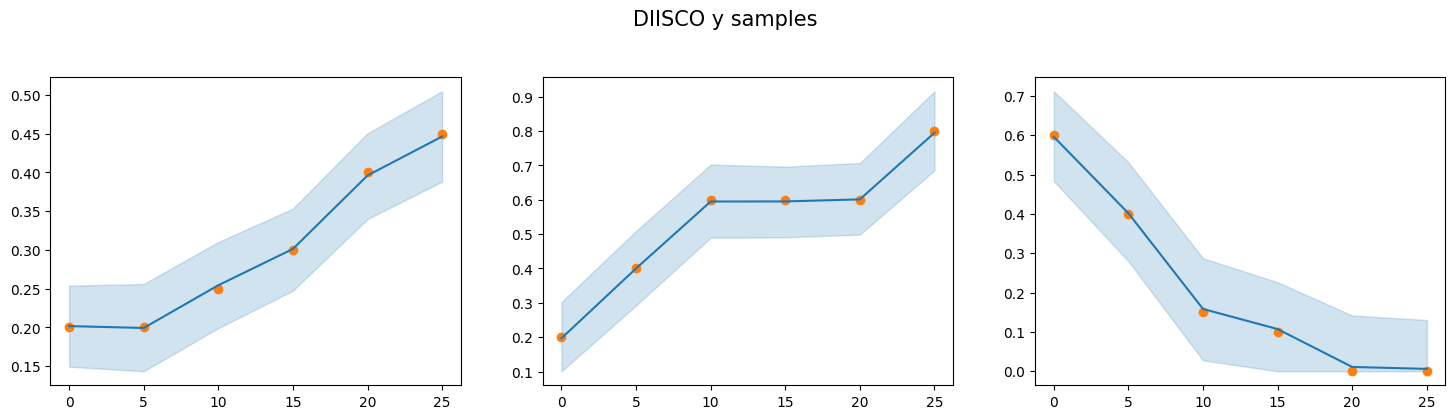

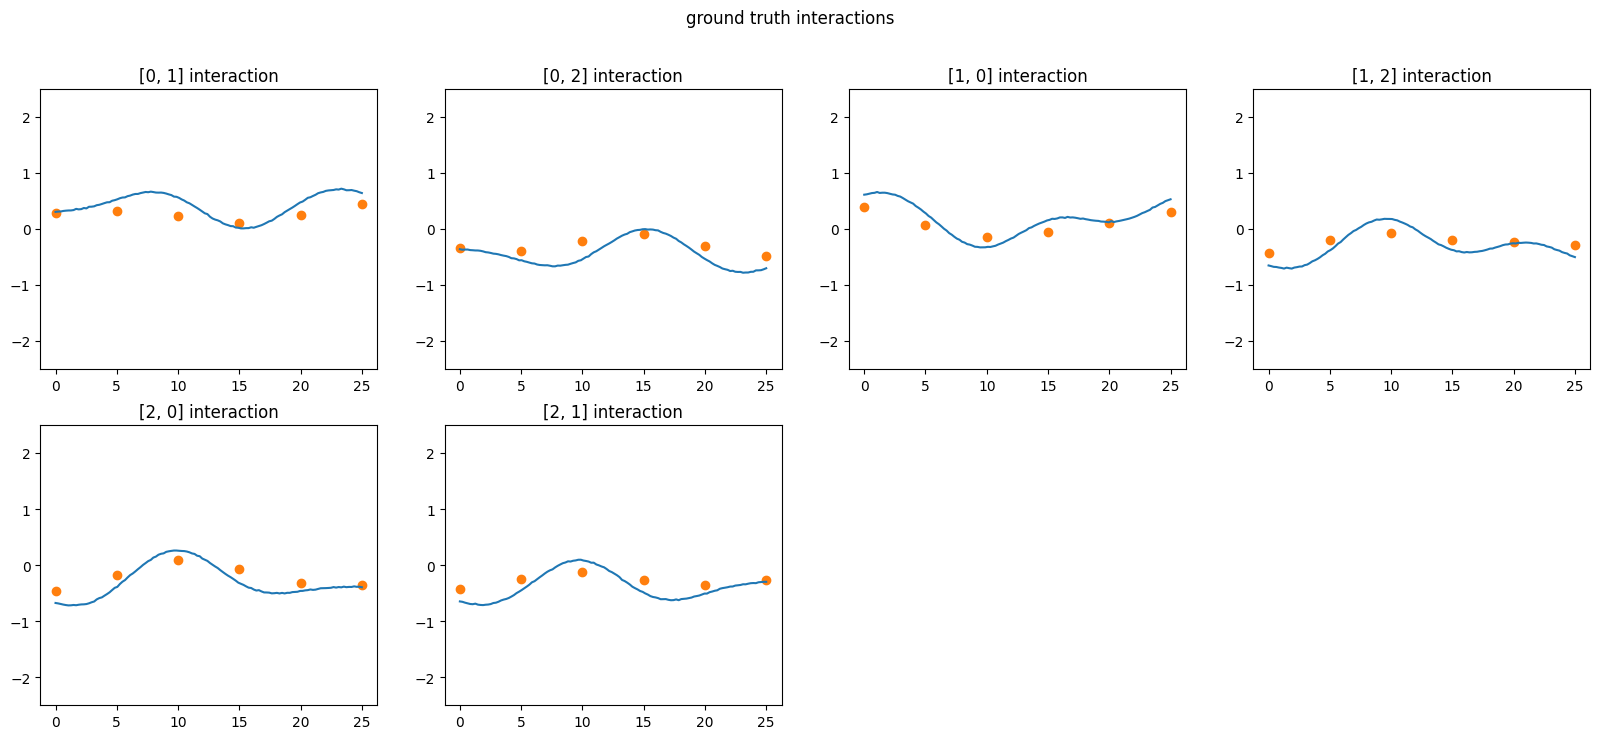

In [10]:
print(data.shape)
# lambda set here
model = DIISCO(lambda_matrix=lambda_prior, hypers_init_vals=hyper_init_vals, verbose=True, verbose_freq=100)

model.fit_and_set_f_prior_params(timepoints=timepoints, proportions=proportions, hypers=model.hypers_init_vals)
model.fit_and_set_w_prior_params(timepoints=timepoints, levels=proteins, hypers=model.hypers_init_vals)    
model.fit(timepoints=timepoints, proportions=proportions, levels=proteins, n_iter=15000, lr=0.00005, guide="MultivariateNormalFactorized")
#model.fit(timepoints=timepoints, proportions=proportions, levels=proteins, n_iter=30000, lr=0.00005, guide="MultivariateNormalFactorized")
        
true_observations = data
predicted_observations = model.sample_observed_proportions(n_samples=1000).detach()
print(predicted_observations.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i in range(3):
    cell_type_samples = predicted_observations[:, :, i]
    mean = unscale(cell_type_samples.mean(axis=0), i)
    percentile_75 = unscale(np.percentile(cell_type_samples, 84, axis=0), i)
    percentile_25 = unscale(np.percentile(cell_type_samples, 16, axis=0), i)
    axes[i].plot(timepoints, mean, c='tab:blue')
    axes[i].fill_between(timepoints.squeeze(), percentile_25, percentile_75, color='tab:blue', alpha=0.2)
    axes[i].scatter(timepoints, unscale(proportions[:, i], i), c='tab:orange')

plt.suptitle('DIISCO y samples', fontsize=15, y=1.05)
    
predict_timepoints = torch.linspace(timepoints.min(), timepoints.max(), 120).reshape(-1, 1)
samples = model.sample(predict_timepoints, 
                       n_samples=1000, 
                       n_samples_per_latent=10,
                       include_emission_variance=True)

W_samples_predict = samples['W']
f_samples_predict = samples['F']
y_samples_predict = samples['Y']
        
interaction_plots = []
for i in range(3):
    for j in range(3):
        # print(i,j)
        if i == j: continue
        w_pred = W_samples_predict[:, :,i, j].detach().numpy()
        if np.max(np.abs(w_pred)) > 0.005: 
            interaction_plots.append([i,j])
                    
n = len(interaction_plots); max_cols = 4
nrows = int(np.ceil(n / max_cols)); ncols = int(min((max_cols, n)))
fig = plt.figure(figsize=[5 * ncols, 4 * nrows])
for i,interaction in enumerate(interaction_plots):
    ax = fig.add_subplot(nrows, ncols, i+1)
    ax.scatter(timepoints, proteins[:, interaction[0], interaction[1]], c='tab:orange')
    ax.plot(predict_timepoints, 
                    W_samples_predict[:, :,interaction[0], interaction[1]].mean(axis=0))
    ax.set_title(f'{interaction} interaction')
    ax.set_ylim(-2.5,2.5)
plt.suptitle("ground truth interactions")
plt.show()

Text(0.5, 1.05, 'DIISCO predicted interactions ($\\hat{W}_{avg})$')

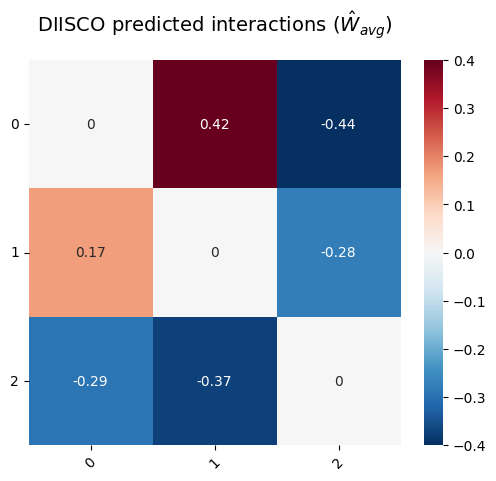

In [11]:
import seaborn as sns

plt.figure(figsize=(6, 5))
W_avg_over_time = W_samples_predict.mean(axis=(0, 1)).detach().numpy()
ax = sns.heatmap(W_avg_over_time, cmap="RdBu_r", annot=True, 
                 vmax=0.4, vmin=-0.4, center=0)
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.title('DIISCO predicted interactions ($\hat{W}_{avg})$', fontsize=14, y=1.05)
# 0 affected by: 2 pos
# 1 affected by: 0 pos
# 2 affected by: 0 neg

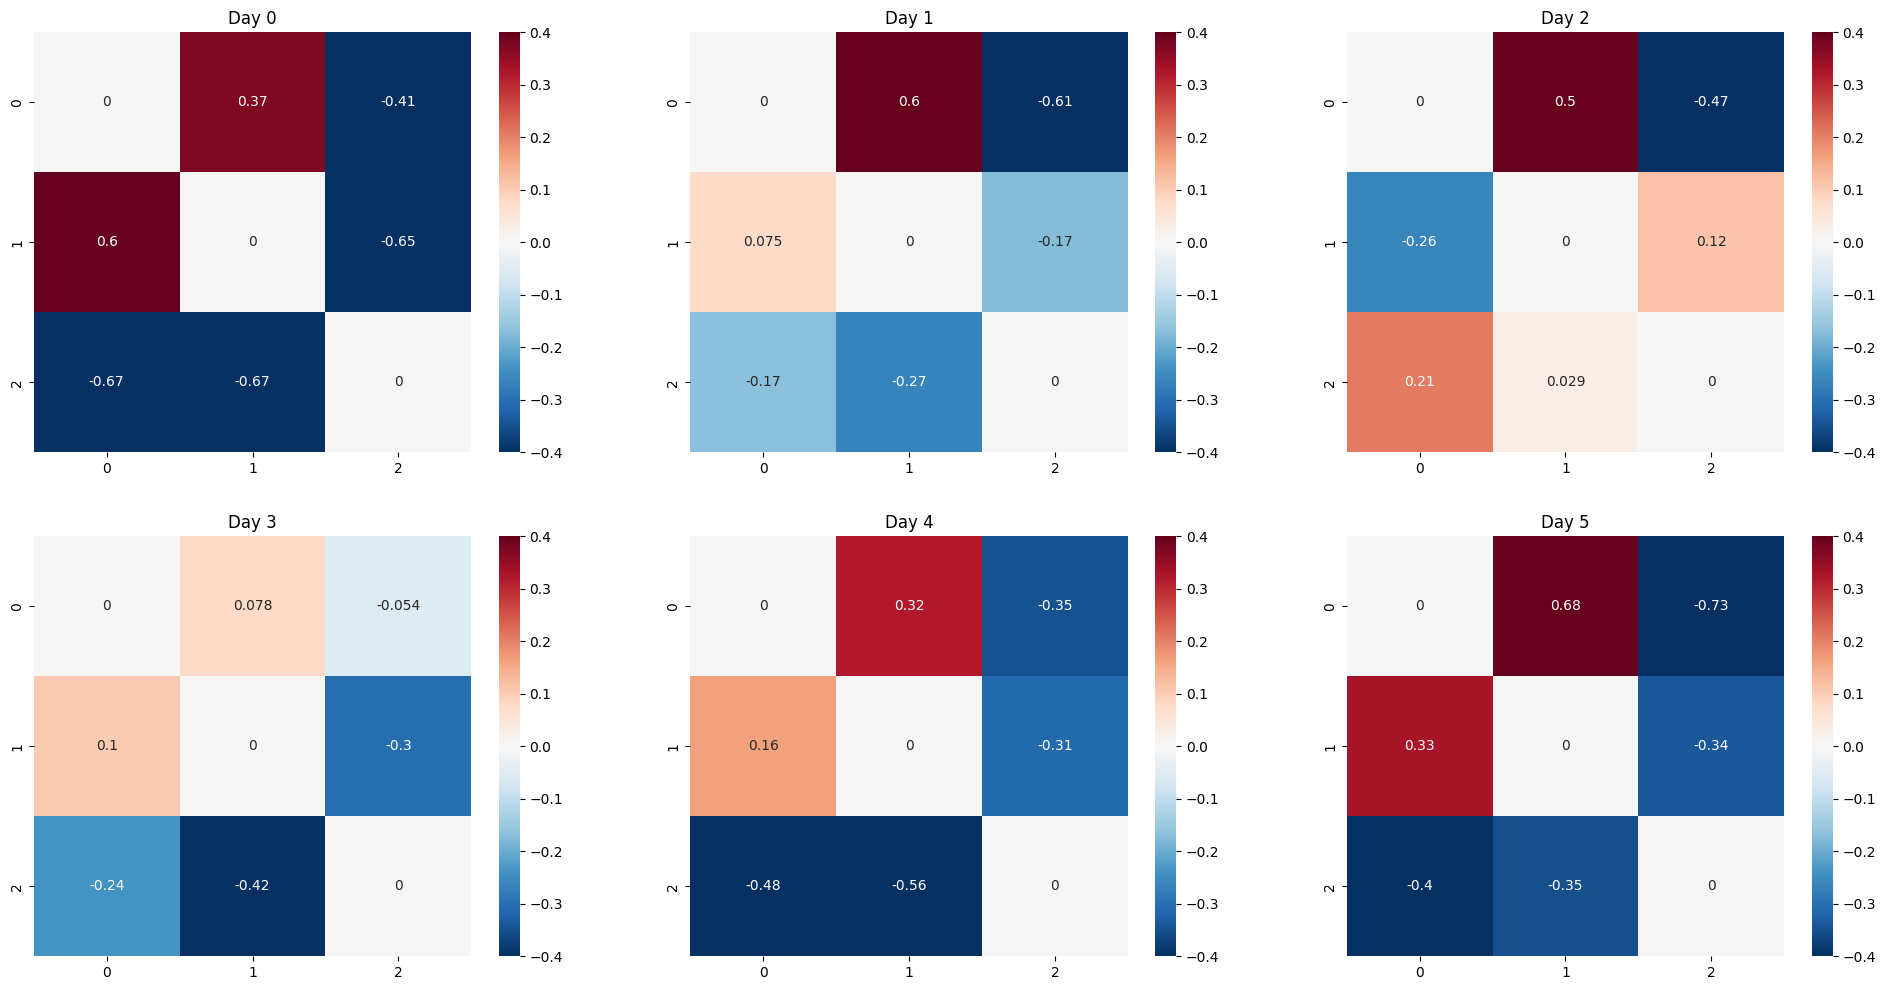

In [12]:
W_avg_per_timepoint = W_samples_predict.mean(axis=(0)).detach().numpy()
W_avg_1 = W_avg_per_timepoint[0:20].mean(axis=(0))
W_avg_2 = W_avg_per_timepoint[20:40].mean(axis=(0))
W_avg_3 = W_avg_per_timepoint[40:60].mean(axis=(0))
W_avg_4 = W_avg_per_timepoint[60:80].mean(axis=(0))
W_avg_5 = W_avg_per_timepoint[80:100].mean(axis=(0))
W_avg_6 = W_avg_per_timepoint[100:120].mean(axis=(0))

fig = plt.figure(figsize=(24, 12))
(row0,row1) = fig.subplots(2, 3)
sns.heatmap(W_avg_1, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row0[0])
row0[0].set_title("Day 0")

sns.heatmap(W_avg_2, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row0[1])
row0[1].set_title("Day 1")

sns.heatmap(W_avg_3, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row0[2])
row0[2].set_title("Day 2")

sns.heatmap(W_avg_4, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row1[0])
row1[0].set_title("Day 3")

sns.heatmap(W_avg_5, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row1[1])
row1[1].set_title("Day 4")

sns.heatmap(W_avg_6, cmap="RdBu_r", annot=True, vmax=0.4, vmin=-0.4, center=0, ax=row1[2])
row1[2].set_title("Day 5")

plt.show()